In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_excel('/content/Financial_risk_assessment_raw1.xlsx')
df.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688.0,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0.0,Port Elizabeth,AS,Cyprus,2.0,2,Low
1,57,Female,Bachelor's,Widowed,NaN,690.0,33835.0,Auto,Employed,6,Fair,0.148920,55849.0,0.0,North Catherine,OH,Turkmenistan,3.0,2,Medium
2,21,Non-binary,Master's,Single,55687.0,600.0,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3.0,South Scott,OK,Luxembourg,3.0,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622.0,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3.0,Robinhaven,PR,Uganda,4.0,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766.0,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,NaN,New Heather,IL,Namibia,3.0,1,Low


In [4]:
#Check null
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    15000 non-null  int64  
 1   Gender                 15000 non-null  object 
 2   Education Level        15000 non-null  object 
 3   Marital Status         15000 non-null  object 
 4   Income                 12750 non-null  float64
 5   Credit Score           12750 non-null  float64
 6   Loan Amount            12750 non-null  float64
 7   Loan Purpose           15000 non-null  object 
 8   Employment Status      15000 non-null  object 
 9   Years at Current Job   15000 non-null  int64  
 10  Payment History        15000 non-null  object 
 11  Debt-to-Income Ratio   15000 non-null  float64
 12  Assets Value           12750 non-null  float64
 13  Number of Dependents   12750 non-null  float64
 14  City                   15000 non-null  object 
 15  St

,0
Age,0
Gender,0
Education Level,0
Marital Status,0
Income,2250
Credit Score,2250
Loan Amount,2250
Loan Purpose,0
Employment Status,0
Years at Current Job,0


In [5]:
#check tỷ lệ null chiếm bn % trong cột dữ liệu
df.shape
df.isnull().mean().sort_values(ascending=False)

,0
Assets Value,0.15
Loan Amount,0.15
Credit Score,0.15
Income,0.15
Number of Dependents,0.15
Previous Defaults,0.15
Gender,0.00
Age,0.00
Marital Status,0.00
Education Level,0.00


In [8]:
#Xử lý null
# Numeric columns → fill median
num_cols = [
    "Income",
    "Credit Score",
    "Loan Amount",
    "Assets Value",
    "Number of Dependents"
]

for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val)


# Previous Defaults → fill median
median_val = df["Previous Defaults"].median()
df["Previous Defaults"].fillna(median_val)


# Categorical → fill "Unknown"
cat_cols = [
    "Gender",
    "Marital Status",
    "Loan Purpose",
    "Employment Status",
    "City",
    "State",
    "Country"
]

for col in cat_cols:
    df[col].fillna("Unknown")


In [9]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Marital Status,0
Income,0
Credit Score,0
Loan Amount,0
Loan Purpose,0
Employment Status,0
Years at Current Job,0


In [10]:
# Check dupplicated
df.duplicated().sum()

np.int64(0)

In [11]:
df['Income'].dtype

dtype('float64')

In [12]:
df['Income'].describe()

,Income
count,15000.000000
mean,69909.338733
std,26887.437667
min,20005.000000
25%,48390.000000
50%,69773.000000
75%,91262.500000
max,119997.000000


In [13]:
df['Assets Value'].dtype
df['Assets Value'].head()

,Assets Value
0,120228.0
1,55849.0
2,180700.0
3,157319.0
4,287140.0


In [14]:
# Check outlier
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Income'] < lower) | (df['Income'] > upper)]

outliers.shape

(0, 20)

In [15]:
Q1 = df['Assets Value'].quantile(0.25)
Q3 = df['Assets Value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Assets Value'] < lower) | (df['Assets Value'] > upper)]

outliers.shape

(0, 20)

In [16]:
Q1 = df['Loan Amount'].quantile(0.25)
Q3 = df['Loan Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Loan Amount'] < lower) | (df['Loan Amount'] > upper)]

outliers.shape

(0, 20)

outlier nằm trong 0 → 20%
Các giá trị Outlier đã được phát hiện trong các biến số tài chính quan trọng như Thu nhập, Giá trị tài sản và Số tiền vay. Tuy nhiên, vì những giá trị này có thể đại diện cho các khách hàng có giá trị cao hợp pháp, nên chúng được giữ lại để phân tích thêm

In [17]:
df['Marital Status Change'].unique()

array([2, 1, 0])

In [18]:
# Phân loại mã hóa dữ liệu cột Marital status
df['Marital Status Change'] = df['Marital Status Change'].map({
    'Single': 1,
    'Widowed': 0,
    'Married/Divorced' : 2
})

In [19]:
df['Marital Status'].unique()

array(['Divorced', 'Widowed', 'Single', 'Married'], dtype=object)

In [20]:
# encode Risk
df['Risk_num'] = df['Risk Rating'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
})

<Figure size 700x400 with 0 Axes>

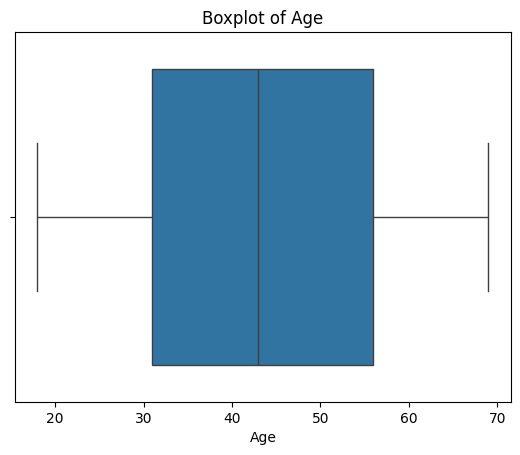

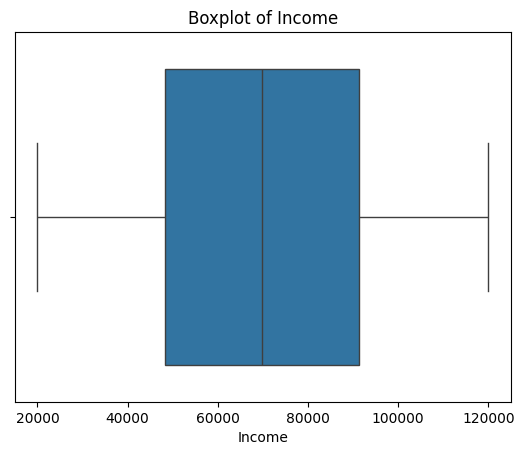

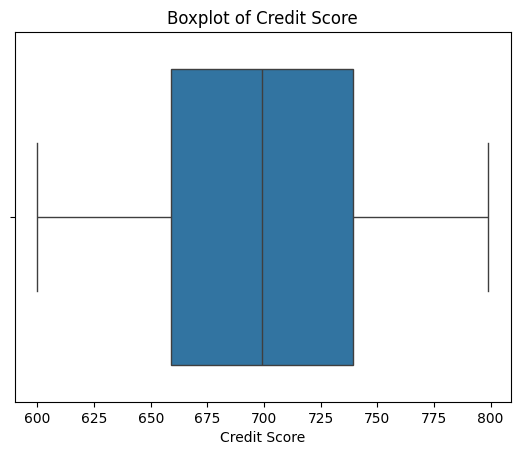

In [21]:
#Distribution (Age / Income / Credit Score)
plt.figure(figsize = (7,4))

cols = ['Age', 'Income', 'Credit Score']
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

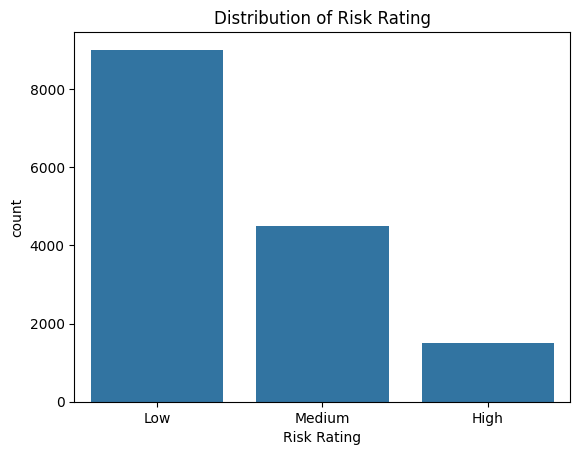

In [22]:
sns.countplot(data=df, x='Risk Rating')
plt.title('Distribution of Risk Rating')
plt.show()

In [23]:
risk_ratio = df['Risk Rating'].value_counts(normalize=True) * 100
print(risk_ratio)

Risk Rating
Low       60.0
Medium    30.0
High      10.0
Name: proportion, dtype: float64


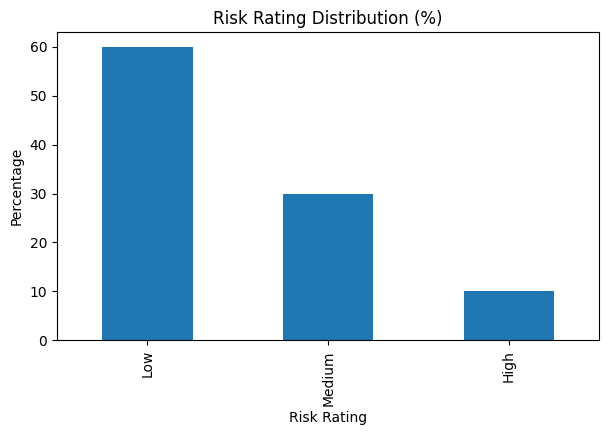

Risk Rating
Low       60.0
Medium    30.0
High      10.0
Name: proportion, dtype: float64


In [24]:
#Risk Distribution
plt.figure(figsize = (7,4))
risk_pct = df['Risk Rating'].value_counts(normalize=True) * 100

risk_pct.plot(kind='bar')

plt.title('Risk Rating Distribution (%)')
plt.ylabel('Percentage')
plt.xlabel('Risk Rating')
plt.show()

print(risk_pct)

In [25]:
#1. Phân tích theo Risk rating
#Credit Score vs Risk
df.groupby('Risk Rating')['Credit Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Rating,,,,,,,,
High,1500.0,699.738000,53.020645,600.0,660.0,699.0,742.0,799.0
Low,9000.0,698.969778,52.880641,600.0,658.0,699.0,739.0,799.0
Medium,4500.0,699.123556,52.449439,600.0,659.0,699.0,740.0,799.0


In [26]:
df.groupby('Risk Rating')['Credit Score'].mean()

,Credit Score
Risk Rating,
High,699.738000
Low,698.969778
Medium,699.123556


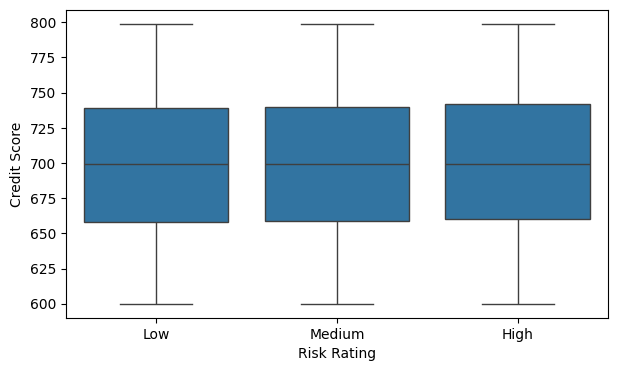

In [27]:
plt.figure(figsize = (7,4))
sns.boxplot(data=df, x='Risk Rating', y='Credit Score')
plt.show()

In [28]:
#Imcome vs Risk
df.groupby('Risk Rating')['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Rating,,,,,,,,
High,1500.0,69130.456000,26347.980217,20016.0,48733.50,69773.0,89512.50,119958.0
Low,9000.0,69644.948667,26902.859104,20005.0,47954.25,69773.0,90862.00,119997.0
Medium,4500.0,70697.746444,27022.233728,20014.0,49217.25,69773.0,92649.75,119978.0


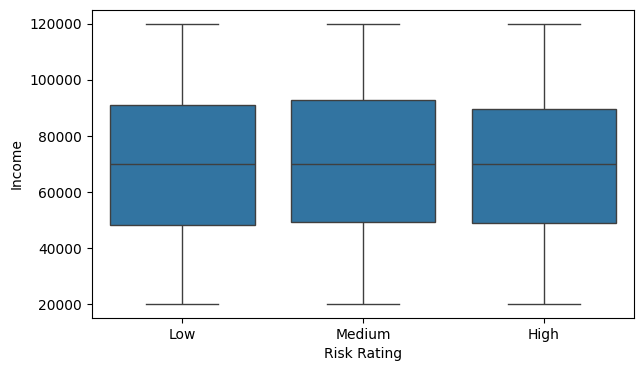

In [29]:
plt.figure(figsize = (7,4))
sns.boxplot(data=df, x='Risk Rating', y='Income')
plt.show()

In [30]:
#Debt-to-Income Ratio vs Risk
df.groupby('Risk Rating')['Debt-to-Income Ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Rating,,,,,,,,
High,1500.0,0.351261,0.143394,0.100479,0.224275,0.354937,0.477838,0.599809
Low,9000.0,0.350018,0.143454,0.100004,0.228683,0.349737,0.474803,0.599970
Medium,4500.0,0.351004,0.145048,0.100135,0.225628,0.351236,0.477326,0.599674


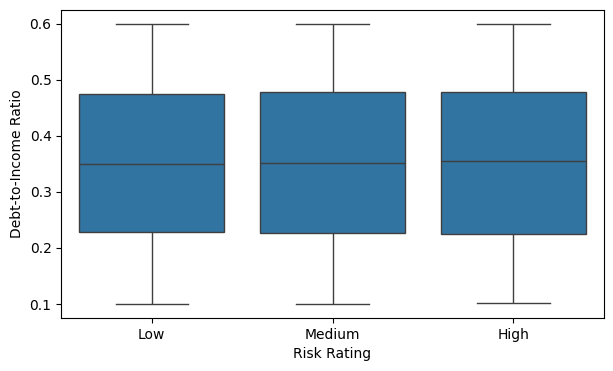

In [31]:
plt.figure(figsize = (7,4))
sns.boxplot(data=df, x='Risk Rating', y='Debt-to-Income Ratio')
plt.show()

DTI càng cao → Risk càng cao => Khách hàng có tỷ lệ nợ trên thu nhập cao hơn sẽ thuộc nhóm rủi ro cao

In [32]:
#Loan Purpose vs Risk
pd.crosstab(df['Loan Purpose'], df['Risk Rating'])

Risk Rating,High,Low,Medium
Loan Purpose,,,
Auto,399,2204,1122
Business,335,2265,1138
Home,373,2255,1138
Personal,393,2276,1102


Business / Personal → risk cao hơn
Home → risk thấp hơn

=> Mục đích vay vốn đóng vai trò quan trọng trong việc đánh giá rủi ro, trong đó các khoản vay kinh doanh có tỷ lệ khách hàng rủi ro cao cao hơn

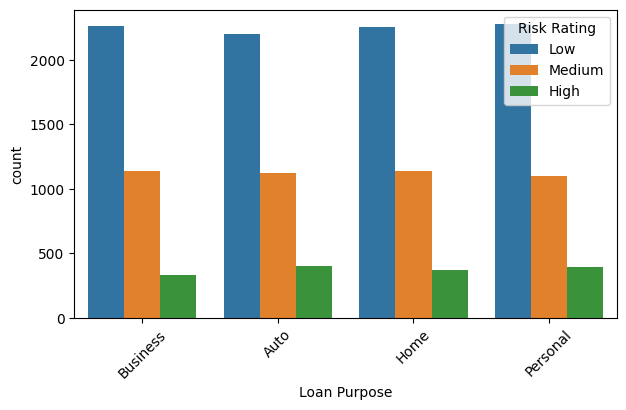

In [33]:
plt.figure(figsize = (7,4))
sns.countplot(data=df, x='Loan Purpose', hue='Risk Rating')
plt.xticks(rotation=45)
plt.show()

In [34]:
#Employment Status vs Risk
pd.crosstab(df['Employment Status'], df['Risk Rating'])

Risk Rating,High,Low,Medium
Employment Status,,,
Employed,517,2964,1545
Self-employed,510,3020,1461
Unemployed,473,3016,1494


Unemployed → High Risk cao
Employed → Low Risk nhiều hơn
=> Những người thất nghiệp có tỷ lệ thuộc nhóm rủi ro cao hơn đáng kể so với khách hàng đang có việc làm

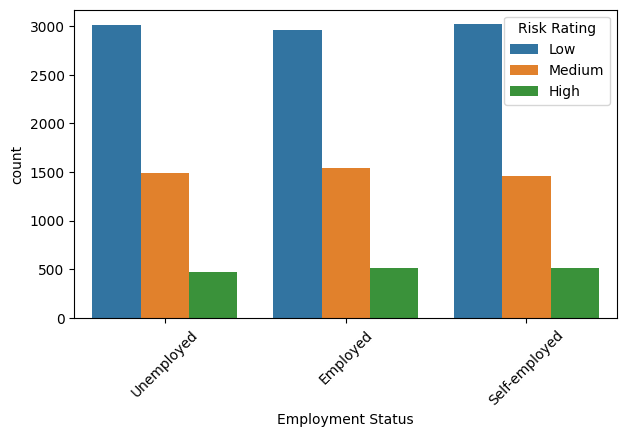

In [35]:
plt.figure(figsize = (7,4))
sns.countplot(data=df, x='Employment Status', hue='Risk Rating')
plt.xticks(rotation=45)
plt.show()

In [36]:
#Payment History vs Risk
pd.crosstab(df['Payment History'], df['Risk Rating'])

Risk Rating,High,Low,Medium
Payment History,,,
Excellent,351,2325,1113
Fair,373,2185,1115
Good,396,2268,1158
Poor,380,2222,1114


Payment History KKhông ảnh hưởng đến Risk Rating

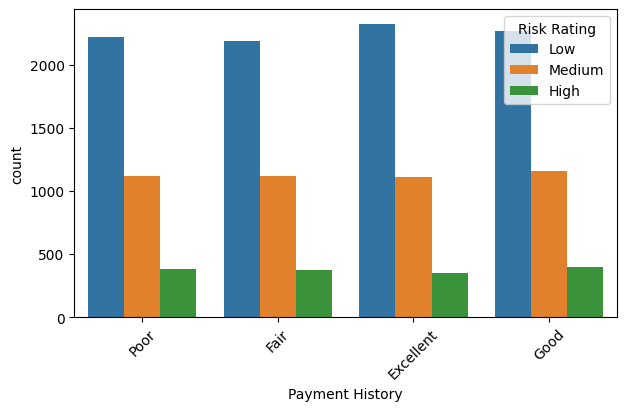

In [37]:
plt.figure(figsize = (7,4))
sns.countplot(data=df, x='Payment History', hue='Risk Rating')
plt.xticks(rotation=45)
plt.show()

In [38]:
#Nhóm khách hàng nào risk cao nhất?
#Unemployed + Payment History
pd.crosstab(
    [df['Employment Status'], df['Payment History']],
    df['Risk Rating'],
    normalize='index'
) * 100

Risk Rating                             High        Low     Medium
Employment Status Payment History                                 
Employed          Excellent         8.900929  58.746130  32.352941
                  Fair             10.457516  57.761438  31.781046
                  Good             10.398749  60.672400  28.928851
                  Poor             11.454102  58.651503  29.894395
Self-employed     Excellent         9.235669  63.773885  26.990446
                  Fair             10.204082  60.244898  29.551020
                  Good             10.888031  58.146718  30.965251
                  Poor             10.534979  59.917695  29.547325
Unemployed        Excellent         9.669621  61.643836  28.686543
                  Fair              9.803922  60.457516  29.738562
                  Good              9.775641  59.214744  31.009615
                  Poor              8.740157  60.787402  30.472441

Employed + Excellent, chỉ có 8.9% là High Risk

Employed + Poor,  High = 11.45% -> Nhóm này có risk cao hơn nhóm Excellent, và là nhóm cao

Nhóm	High Risk
Employed + Excellent	~8.9%
Employed + Poor	~11.45%
Self-employed + Good	~10.8%
Unemployed + Poor	~8.7%
=> Khách hàng có lịch sử thanh toán kém thường có mức độ rủi ro cao hơn bất kể tình trạng việc làm. Điều thú vị là, những người đang làm việc nhưng có lịch sử thanh toán kém lại có tỷ lệ trường hợp rủi ro cao cao nhất.
==> Lịch sử thanh toán dường như là yếu tố quyết định rủi ro mạnh hơn so với tình trạng việc làm, vì tỷ lệ rủi ro cao vẫn tương đối ổn định giữa các nhóm việc làm.

==> Khách hàng có rủi ro cao thường có đặc điểm là thất nghiệp, lịch sử thanh toán kém và tỷ lệ nợ trên thu nhập cao. Ngoài ra, một số mục đích vay vốn nhất định, chẳng hạn như vay kinh doanh, cũng đi kèm với mức độ rủi ro cao hơn

In [39]:
#Credit Score có phản ánh Risk không?
df.groupby('Risk Rating')['Credit Score'].mean().sort_values()

,Credit Score
Risk Rating,
Low,698.969778
Medium,699.123556
High,699.738000


=> Điểm tín dụng không cho thấy sự khác biệt đáng kể giữa các nhóm rủi ro, điều này cho thấy rằng nó có thể không phải là yếu tố dự báo rủi ro mạnh trong dataset này

In [40]:
#Tính correlation
df[['Income', 'Debt-to-Income Ratio', 'Risk_num']].corr()

,Income,Debt-to-Income Ratio,Risk_num
Income,1.000000,-0.000653,0.004477
Debt-to-Income Ratio,-0.000653,1.000000,0.003465
Risk_num,0.004477,0.003465,1.000000


=> Correlation nằm trong khoảng ≈ 0
=> Income KHÔNG liên quan đến Risk
DTI CŨNG KHÔNG liên quan rõ ràng

==>Phân tích tương quan chỉ ra rằng cả Thu nhập và Tỷ lệ nợ trên thu nhập đều không có mối quan hệ tuyến tính đáng kể với Xếp hạng rủi ro, cho thấy rằng chỉ riêng các biến này không phải là yếu tố dự báo rủi ro mạnh mẽ trong tập dữ liệu này.

Như vậy Income và DTI ko có yếu tố nào mạnh ảnh hưởng đến Risk

In [41]:
#Chi-square
from scipy.stats import chi2_contingency

cols = ['Employment Status', 'Loan Purpose', 'Payment History']

for col in cols:
    table = pd.crosstab(df[col], df['Risk Rating'])
    chi2, p, dof, expected = chi2_contingency(table)

    print(col, "p-value:", p)

Employment Status p-value: 0.28104443345073216
Loan Purpose p-value: 0.2077302795545148
Payment History p-value: 0.5147717061397008


=> Kiểm định chi-square cho thấy Tình trạng việc làm, Mục đích vay và Lịch sử thanh toán không có mối quan hệ có ý nghĩa thống kê với Xếp hạng rủi ro.

In [42]:
#Kiểm định ANOVA test biến numeric có khác nhau giữa các nhóm Risk không
from scipy import stats

groups = [group['Debt-to-Income Ratio'].values for name, group in df.groupby('Risk Rating')]

f_stat, p_value = stats.f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 0.09773321515296085
p-value: 0.9068913938152899


In [43]:
cols = ['Income', 'Debt-to-Income Ratio', 'Credit Score']

for col in cols:
    groups = [group[col].values for name, group in df.groupby('Risk Rating')]
    f, p = stats.f_oneway(*groups)
    print(col, "p-value:", p)

Income p-value: 0.04982393363312398
Debt-to-Income Ratio p-value: 0.9068913938152899
Credit Score p-value: 0.8716558036097449


=> Ko có yếu tố nào ảnh hưởng mạnh đến Risk có ý nghĩa về mặt thống kê

==> Phân tích cho thấy không có biến số nào được xem xét, bao gồm Thu nhập, Tỷ lệ nợ trên thu nhập, Điểm tín dụng, Tình trạng việc làm, Mục đích vay và Lịch sử thanh toán, cho thấy mối quan hệ có ý nghĩa thống kê với Xếp hạng rủi ro.

Cả phân tích tương quan và kiểm định chi-square đều cho thấy các đặc điểm này chỉ giải thích tối thiểu trong việc dự đoán rủi ro của khách hàng.

Điều này hiểu rằng tập dữ liệu hiện tại không chứa đủ thông tin để xác định chính xác các yếu tố chính gây ra rủi ro.

Các khuyến nghị:
Việc thiếu các mối quan hệ chặt chẽ cho thấy rằng việc phân loại rủi ro trong tập dữ liệu này có thể không dựa trên các chỉ số tài chính có thể quan sát được, mà là do các yếu tố bên ngoài hoặc không thể quan sát được

- Thu thập thêm các biến số phản ánh tốt hơn hành vi tài chính của khách hàng, chẳng hạn như lịch sử trả nợ, tình trạng nợ quá hạn hoặc mô hình giao dịch.

- Đánh giá lại định nghĩa Xếp hạng Rủi ro để đảm bảo nó dựa trên các tiêu chí có ý nghĩa và có thể đo lường được. Cải thiện độ chi tiết của dữ liệu để nắm bắt sự khác biệt giữa các phân khúc khách hàng.

- Xem xét áp dụng các kỹ thuật học máy với tập dữ liệu phong phú hơn để khám phá các mô hình ẩn: Xác thực xem Xếp hạng Rủi ro được tạo ra từ các quy tắc thực tế hay được gán ngẫu nhiên






In [44]:
#Previous Defaults vs Risk
# Tạo biến binary
df['default_flag'] = df['Previous Defaults'].apply(lambda x: 'Has Default' if x > 0 else 'No Default')

In [45]:
#đếm số lượng
pd.crosstab(df['default_flag'], df['Risk Rating'])

Risk Rating,High,Low,Medium
default_flag,,,
Has Default,1255,7397,3777
No Default,245,1603,723


In [46]:
#Tính tỷ lệ High Risk
pd.crosstab(df['default_flag'], df['Risk Rating'], normalize='index')

Risk Rating,High,Low,Medium
default_flag,,,
Has Default,0.100974,0.595140,0.303886
No Default,0.095294,0.623493,0.281214


Nhóm
Has Default	với High Risk 10.3%
No Default với High Risk	9.35%
Chênh lệch ≈ 1%
=> Previous Defaults gần như KHÔNG ảnh hưởng đến Risk Rating

In [47]:
#Assets Value vs Risk
#Chia nhóm
def asset_group(x):
    if x < 50000:
        return 'Low Assets'
    elif x <= 150000:
        return 'Medium Assets'
    else:
        return 'High Assets'

df['asset_group'] = df['Assets Value'].apply(asset_group)

In [48]:
pd.crosstab(df['asset_group'], df['Risk Rating'], normalize='index')

Risk Rating,High,Low,Medium
asset_group,,,
High Assets,0.103110,0.600904,0.295986
Low Assets,0.093865,0.619364,0.286770
Medium Assets,0.095654,0.592487,0.311858


Nhóm
High Assets	-	High Risk 10.31%
Medium Assets -	High Risk 	9.56%
Low Assets- 	High Risk	9.39%
Chênh lệch ~1%

=> Assets Value KHÔNG ảnh hưởng đến Risk Rating

In [49]:
#Loan Amount vs Risk
#Chia nhóm
def loan_group(x):
    if x < 10000:
        return 'Small Loan'
    elif x <= 30000:
        return 'Medium Loan'
    else:
        return 'Large Loan'

df['loan_group'] = df['Loan Amount'].apply(loan_group)

In [50]:
pd.crosstab(df['loan_group'], df['Risk Rating'], normalize='index')

Risk Rating,High,Low,Medium
loan_group,,,
Large Loan,0.103564,0.593507,0.302929
Medium Loan,0.099949,0.602230,0.297821
Small Loan,0.086231,0.613352,0.300417


Nhóm
Large Loan -High Risk	10.36%
Medium Loan	-High Risk 9.85%
Small Loan - High Risk	8.62%
Chênh lệch ≈ 1.7%
-> Loan Amount có ảnh hưởng nhẹ đến Risk Rating


In [51]:
def high_risk_rate(group_col):
    return (
        df.groupby(group_col)['Risk Rating']
        .apply(lambda x: (x == 'High').mean())
        .sort_values(ascending=False)
    )

high_risk_rate('default_flag')
high_risk_rate('asset_group')
high_risk_rate('loan_group')

,Risk Rating
loan_group,
Large Loan,0.103564
Medium Loan,0.099949
Small Loan,0.086231
